<a href="https://colab.research.google.com/github/sushantanand1234-sudo/Marketing-Campaign-Analysis/blob/main/A_B_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# ===========================
# Import Required Libraries
# ===========================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Analysis
import scipy.stats as st

# Machine Learning
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

# Time Series Analysis
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, coint

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Plot Settings
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [4]:
from google.colab import files
import pandas as pd

# Upload the file
uploaded = files.upload()

# Read the Excel file
df = pd.read_excel('market campaign (1).xlsx')

# Display dataset
df.head()

Saving market campaign.xlsx to market campaign (2).xlsx


,Date,Facebook Ad Campaign,Facebook Ad Views,Facebook Ad Clicks,Facebook Ad Conversions,Cost per Facebook Ad,Facebook Click-Through Rate (Clicks / View),Facebook Conversion Rate (Conversions / Clicks),Facebook Cost per Click (Ad Cost / Clicks),AdWords Ad Campaign,AdWords Ad Views,AdWords Ad Clicks,AdWords Ad Conversions,Cost per AdWords Ad,AdWords Click-Through Rate (Clicks / View),AdWords Conversion Rate (Conversions / Clicks),AdWords Cost per Click (Ad Cost / Clicks)
0,01/01/2019,FB_Jan19,5652,150,39,208,2.65%,26.00%,$1.39,AW_Jan19,6105,127,19,73,2.08%,14.96%,$0.57
1,01/02/2019,FB_Jan19,5949,142,49,202,2.39%,34.51%,$1.42,AW_Jan19,3995,123,16,238,3.08%,13.01%,$1.93
2,01/03/2019,FB_Jan19,4328,72,21,137,1.66%,29.17%,$1.90,AW_Jan19,5786,112,11,149,1.94%,9.82%,$1.33
3,01/04/2019,FB_Jan19,5139,92,30,83,1.79%,32.61%,$0.90,AW_Jan19,3157,106,8,182,3.36%,7.55%,$1.72
4,01/05/2019,FB_Jan19,3650,103,49,198,2.82%,47.57%,$1.92,AW_Jan19,5808,77,6,137,1.33%,7.79%,$1.78


In [5]:
df.shape


(365, 17)

In [6]:
df.dtypes

,0
Date,object
Facebook Ad Campaign,object
Facebook Ad Views,int64
Facebook Ad Clicks,int64
Facebook Ad Conversions,int64
Cost per Facebook Ad,int64
Facebook Click-Through Rate (Clicks / View),object
Facebook Conversion Rate (Conversions / Clicks),object
Facebook Cost per Click (Ad Cost / Clicks),object
AdWords Ad Campaign,object


In [9]:
#converting date to datetime
df['Date']=pd.to_datetime(df['Date'])

In [10]:
df.describe()

,Date,Facebook Ad Views,Facebook Ad Clicks,Facebook Ad Conversions,Cost per Facebook Ad,AdWords Ad Views,AdWords Ad Clicks,AdWords Ad Conversions,Cost per AdWords Ad
count,365,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000
mean,2019-07-02 00:00:00,3433.890411,64.693151,23.542466,142.750685,4531.945205,106.235616,13.591781,157.638356
min,2019-01-01 00:00:00,1001.000000,10.000000,4.000000,61.000000,2021.000000,28.000000,3.000000,70.000000
25%,2019-04-02 00:00:00,2079.000000,35.000000,13.000000,106.000000,3340.000000,66.000000,8.000000,115.000000
50%,2019-07-02 00:00:00,3559.000000,60.000000,21.000000,143.000000,4521.000000,98.000000,12.000000,154.000000
75%,2019-10-01 00:00:00,4748.000000,89.000000,32.000000,183.000000,5819.000000,143.000000,18.000000,201.000000
max,2019-12-31 00:00:00,5998.000000,163.000000,72.000000,220.000000,6998.000000,227.000000,39.000000,250.000000
std,NaN,1477.197662,35.274031,13.544249,47.226724,1434.021251,49.081389,7.455025,52.759569


**Compairing Campaign Performance**

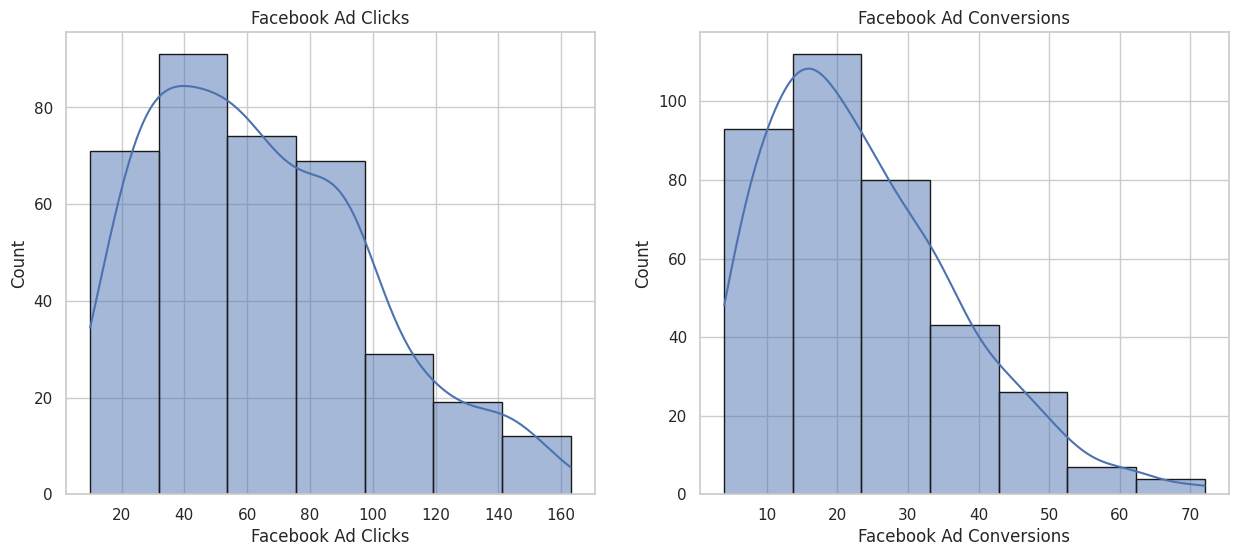

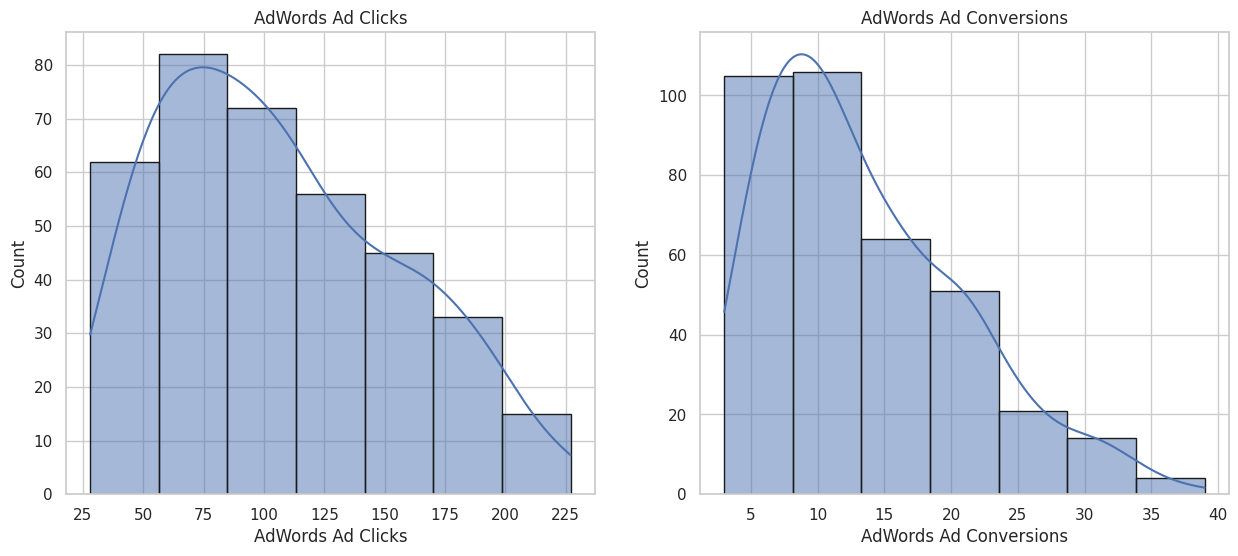

In [11]:
# distribution of the clicks and conversions
plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
plt.title('Facebook Ad Clicks')
sns.histplot(df['Facebook Ad Clicks'], bins=7, edgecolor='k', kde=True)

plt.subplot(1,2,2)
plt.title('Facebook Ad Conversions')
sns.histplot(df['Facebook Ad Conversions'], bins=7, edgecolor='k', kde=True)

plt.show()


plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
plt.title('AdWords Ad Clicks')
sns.histplot(df['AdWords Ad Clicks'], bins=7, edgecolor='k', kde=True)

plt.subplot(1,2,2)
plt.title('AdWords Ad Conversions')
sns.histplot(df['AdWords Ad Conversions'], bins=7, edgecolor='k', kde=True)

plt.show()

How frequently do we observe days with high numbers of conversions compared to days with low numbers of conversions?

In [12]:
# creating function to calculate the category for the conversions

def create_conversion_category(conversion_col):
    category = []

    for conversion in df[conversion_col]:

        if conversion < 6:
            category.append('less than 6')

        elif 6 <= conversion < 11:
            category.append('6 - 10')

        elif 11 <= conversion < 16:
            category.append('10 - 15')

        else:
            category.append('more than 15')

    return category


# applying function for different campaign's conversions

df['Facebook Conversion Category'] = create_conversion_category('Facebook Ad Conversions')

df['AdWords Conversion Category'] = create_conversion_category('AdWords Ad Conversions')

In [13]:
df[['Facebook Ad Conversions',
    'Facebook Conversion Category',
    'AdWords Ad Conversions',
    'AdWords Conversion Category']].head()

,Facebook Ad Conversions,Facebook Conversion Category,AdWords Ad Conversions,AdWords Conversion Category
0,39,more than 15,19,more than 15
1,49,more than 15,16,more than 15
2,21,more than 15,11,10 - 15
3,30,more than 15,8,6 - 10
4,49,more than 15,6,6 - 10


In [14]:
df['Facebook Conversion Category'].value_counts()

,count
Facebook Conversion Category,
more than 15,242
10 - 15,60
6 - 10,51
less than 6,12


In [15]:
df['Facebook Ad Conversions'].describe()

,Facebook Ad Conversions
count,365.000000
mean,23.542466
std,13.544249
min,4.000000
25%,13.000000
50%,21.000000
75%,32.000000
max,72.000000


In [16]:
df['Facebook Ad Conversions'].max()

72

In [24]:
# Facebook conversion category counts
facebook = df['Facebook Conversion Category'].value_counts().reset_index()
facebook = facebook.rename(columns={'Facebook Conversion Category': 'Category'})
facebook

,Category,count
0,more than 15,242
1,10 - 15,60
2,6 - 10,51
3,less than 6,12


In [18]:
# AdWords conversion category counts
df['AdWords Conversion Category'].value_counts()

,count
AdWords Conversion Category,
more than 15,127
6 - 10,116
10 - 15,81
less than 6,41


In [26]:
adwords = df['AdWords Conversion Category'].value_counts().reset_index()
adwords = adwords.rename(columns={'AdWords Conversion Category': 'Category'})
adwords

,Category,count
0,more than 15,127
1,6 - 10,116
2,10 - 15,81
3,less than 6,41


In [28]:
# Merge both dataframes
category_df = pd.merge(
    facebook,
    adwords,
    on='Category',
    how='outer',
    suffixes=('_facebook', '_adwords')
).fillna(0)

category_df

,Category,count_facebook,count_adwords
0,10 - 15,60,81
1,6 - 10,51,116
2,less than 6,12,41
3,more than 15,242,127


In [29]:
# Reorder rows
category_df = category_df.iloc[[3,1,0,2]]

category_df

,Category,count_facebook,count_adwords
3,more than 15,242,127
1,6 - 10,51,116
0,10 - 15,60,81
2,less than 6,12,41


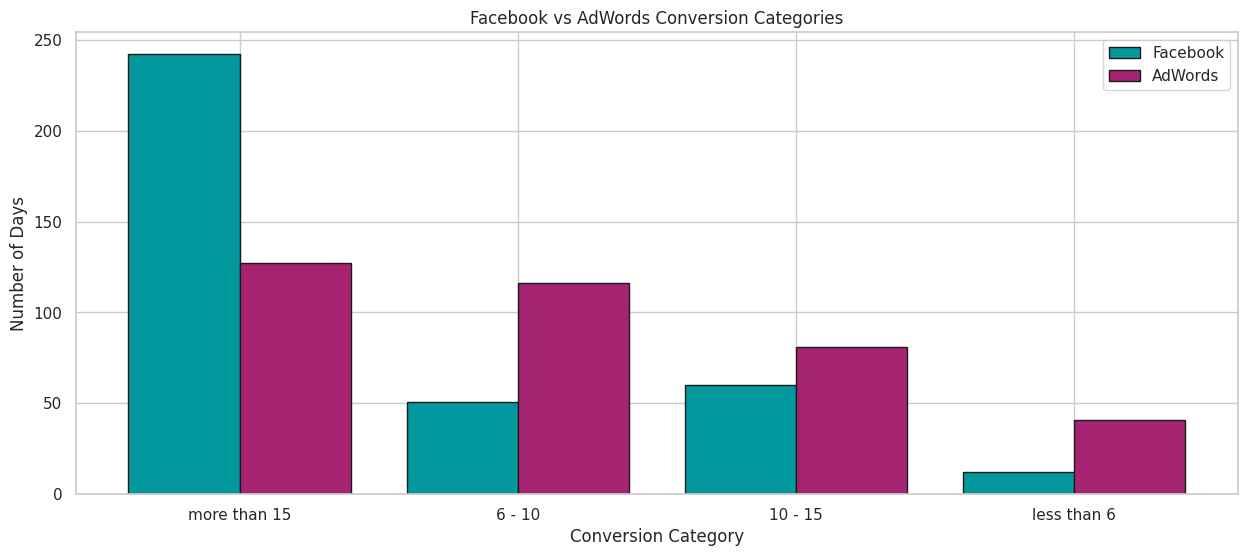

In [31]:
# Plot comparison
X_axis = np.arange(len(category_df))

plt.figure(figsize=(15,6))

plt.bar(
    X_axis - 0.2,
    category_df['count_facebook'],
    0.4,
    label='Facebook',
    color='#03989E',
    linewidth=1,
    edgecolor='k'
)

plt.bar(
    X_axis + 0.2,
    category_df['count_adwords'],
    0.4,
    label='AdWords',
    color='#A62372',
    linewidth=1,
    edgecolor='k'
)

plt.xticks(X_axis, category_df['Category'])
plt.xlabel('Conversion Category')
plt.ylabel('Number of Days')
plt.title('Facebook vs AdWords Conversion Categories')
plt.legend()
plt.show()

Facebook generated substantially more days with more than 15 conversions, indicating superior peak campaign performance.

AdWords recorded more days within the 6–10 and 10–15 conversion ranges, suggesting steadier campaign outcomes.

Both platforms experienced relatively few low-conversion days, demonstrating effective campaign execution.

Businesses seeking maximum conversions may benefit more from Facebook campaigns, while AdWords offers a more balanced and consistent conversion profile.

**Q. Do more clicks on the ad really lead to more sales?**

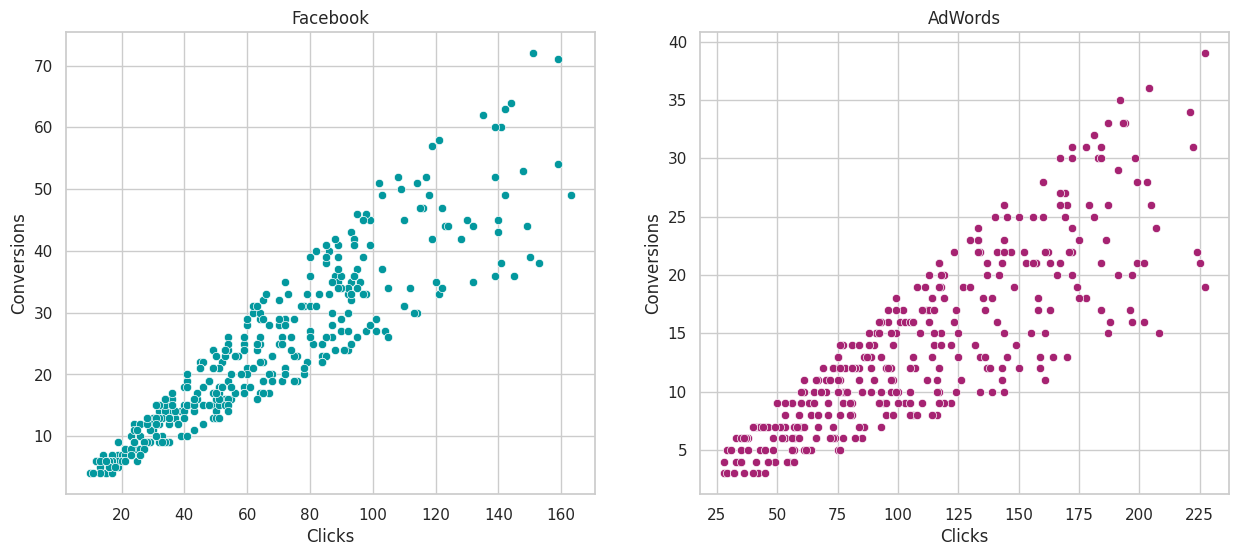

In [32]:
# Do more clicks on the ad really lead to more sales?

plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
plt.title('Facebook')
sns.scatterplot(
    x=df['Facebook Ad Clicks'],
    y=df['Facebook Ad Conversions'],
    color='#03989E'
)
plt.xlabel('Clicks')
plt.ylabel('Conversions')

plt.subplot(1,2,2)
plt.title('AdWords')
sns.scatterplot(
    x=df['AdWords Ad Clicks'],
    y=df['AdWords Ad Conversions'],
    color='#A62372'
)
plt.xlabel('Clicks')
plt.ylabel('Conversions')

plt.show()

In [33]:
facebook_corr = df[['Facebook Ad Conversions',
                    'Facebook Ad Clicks']].corr()

facebook_corr

,Facebook Ad Conversions,Facebook Ad Clicks
Facebook Ad Conversions,1.000000,0.915609
Facebook Ad Clicks,0.915609,1.000000


In [34]:
adwords_corr = df[['AdWords Ad Conversions',
                   'AdWords Ad Clicks']].corr()

adwords_corr

,AdWords Ad Conversions,AdWords Ad Clicks
AdWords Ad Conversions,1.00000,0.84713
AdWords Ad Clicks,0.84713,1.00000


In [35]:
print('Correlation Coeff \n-------------------')

print('Facebook :', round(facebook_corr.values[0,1], 2))

print('AdWords  :', round(adwords_corr.values[0,1], 2))

Correlation Coeff 
-------------------
Facebook : 0.92
AdWords  : 0.85


The correlation analysis shows a strong positive relationship between ad clicks and conversions for both Facebook and AdWords campaigns. This indicates that campaigns generating more user clicks generally achieve higher numbers of conversions.

Facebook has a higher correlation coefficient (0.92) compared to AdWords (0.85). This suggests that Facebook clicks are more consistently associated with successful conversions, indicating a stronger connection between user engagement and purchase behavior.

Since Facebook exhibits the strongest relationship between clicks and conversions, businesses may consider allocating a larger share of their advertising budget to Facebook campaigns while continuing to optimize AdWords campaigns to improve click quality and conversion performance.

**Hypothesis Testing**

**Hypothesis:**

Advertising on Facebook results in a greater number of conversions than advertising on AdWords.

**Null Hypothesis (H₀)**

There is no significant difference in the mean number of conversions between Facebook and AdWords, or AdWords performs equally well or better.

H₀: μFacebook ≤ μAdWords

**Alternative Hypothesis (H₁)**

Facebook generates more conversions than AdWords.

H₁: μFacebook > μAdWords

In [36]:
# Mean conversions for both campaigns

print('Mean Conversion \n----------------------')

print('Facebook :', round(df['Facebook Ad Conversions'].mean(), 2))

print('AdWords  :', round(df['AdWords Ad Conversions'].mean(), 2))

Mean Conversion 
----------------------
Facebook : 23.54
AdWords  : 13.59


In [37]:
# Perform Independent Two-Sample t-test

t_stats, p_value = st.ttest_ind(
    a=df['Facebook Ad Conversions'],
    b=df['AdWords Ad Conversions'],
    equal_var=False
)

print('\nT statistic', t_stats, '\n\np-value', p_value)


T statistic 12.29641678224541 

p-value 5.767854357099142e-31


In [38]:
# Compare p-value with significance level (α = 0.05)

if p_value < 0.05:
    print("\np-value is less than significance value, Reject the null hypothesis")
else:
    print("\np-value is greater than significance value, Accept the null hypothesis")


p-value is less than significance value, Reject the null hypothesis


**Interpretation of the Hypothesis Test**

The hypothesis test produced a p-value less than the significance level (0.05). Therefore, the null hypothesis (H₀) is rejected.

This indicates that the difference in the average number of conversions between Facebook and AdWords is statistically significant and is unlikely to have occurred due to random chance.

The average number of conversions for Facebook campaigns (23.54) is considerably higher than that of AdWords campaigns (13.59). This indicates that Facebook advertisements were more effective at converting users into customers throughout the campaign period.

These findings provide strong statistical evidence that Facebook campaigns generated significantly more conversions than AdWords campaigns in this dataset, making Facebook the more effective advertising platform for driving conversions.

**Regression Analysis**

**Q.What will happen when I go with the Facebook Ad? How many Facebook ad conversions can I expect given a certain number of Facebook ad clicks?**

In [39]:
# independent variable
X = df[['Facebook Ad Clicks']]

# dependent variable
y = df['Facebook Ad Conversions']

# initializing and fitting Linear Regression model
reg_model = LinearRegression()
reg_model.fit(X, y)

prediction = reg_model.predict(X)

# model evaluation
r2 = r2_score(y, prediction) * 100
mse = mean_squared_error(y, prediction)

print("Accuracy (R2 Score):", round(r2, 2), "%")
print("Mean Squared Error:", round(mse, 2))

Accuracy (R2 Score): 83.83 %
Mean Squared Error: 29.57


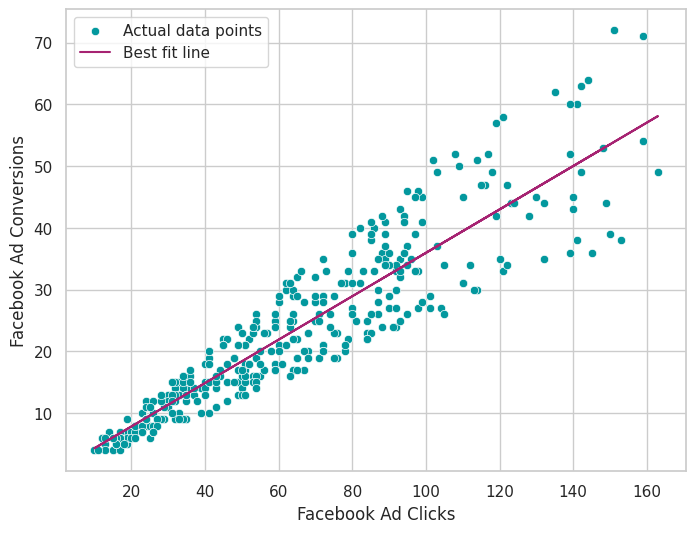

In [40]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Facebook Ad Clicks'],
    y=df['Facebook Ad Conversions'],
    color='#03989E',
    label='Actual data points'
)

plt.plot(
    df['Facebook Ad Clicks'],
    prediction,
    color='#A62372',
    label='Best fit line'
)

plt.legend()
plt.show()

In [41]:
print(
    f"For {50} Clicks, Expected Conversion : "
    f"{round(reg_model.predict([[50]])[0], 2)}"
)

print(
    f"For {80} Clicks, Expected Conversion : "
    f"{round(reg_model.predict([[80]])[0], 2)}"
)

For 50 Clicks, Expected Conversion : 18.38
For 80 Clicks, Expected Conversion : 28.92


1.The regression model achieved an R² score of 83.83%, indicating that Facebook ad clicks explain a large proportion of the variation in conversions. This suggests that clicks are a strong predictor of conversion performance.

2.The Mean Squared Error (29.57) indicates that the model's prediction errors are relatively low, demonstrating good predictive performance for this dataset.

3.The scatter plot and best-fit line show a strong positive linear relationship between Facebook ad clicks and conversions, meaning that campaigns with more clicks generally generate more conversions.

4.Based on the model, 50 ad clicks are expected to generate approximately 18.38 conversions, while 80 ad clicks are expected to generate approximately 28.92 conversions. This enables marketers to estimate expected conversions based on campaign traffic.

5.The regression model can support campaign planning, budget allocation, and performance forecasting by providing estimated conversions for different click volumes.









**Analyzing Fcaebook Campaign Metrics Over Time**

In [44]:
# cleaning data (removing unwanted symbols from the columns and converting them to numerical columns)

df['Facebook Click-Through Rate (Clicks / View)'] = \
df['Facebook Click-Through Rate (Clicks / View)'].astype(str).apply(lambda x: float(x[:-1]))

df['Facebook Conversion Rate (Conversions / Clicks)'] = \
df['Facebook Conversion Rate (Conversions / Clicks)'].astype(str).apply(lambda x: float(x[:-1]))

df['Facebook Cost per Click (Ad Cost / Clicks)'] = \
df['Facebook Cost per Click (Ad Cost / Clicks)'].astype(str).apply(lambda x: float(x[1:]))

In [45]:
# filtering for facebook campaign

df = df[[
    'Date',
    'Facebook Ad Views',
    'Facebook Ad Clicks',
    'Facebook Ad Conversions',
    'Cost per Facebook Ad',
    'Facebook Click-Through Rate (Clicks / View)',
    'Facebook Conversion Rate (Conversions / Clicks)',
    'Facebook Cost per Click (Ad Cost / Clicks)'
]]

**Q.At what times of the month or days of the week do we observe the most conversions?**

In [46]:
# extracting month and week day from the date column

df['month'] = df['Date'].dt.month
df['week'] = df['Date'].dt.weekday

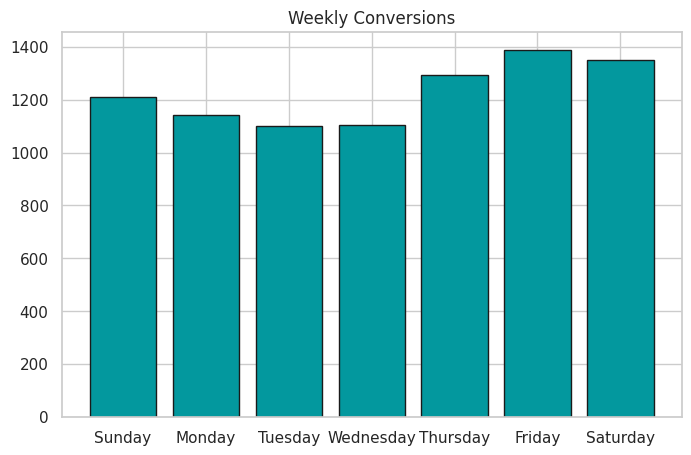

In [47]:
plt.figure(figsize=(8,5))

plt.title('Weekly Conversions')

weekly_conversion = df.groupby('week')[['Facebook Ad Conversions']].sum()

week_names = [
    'Sunday',
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday'
]

plt.bar(
    week_names,
    weekly_conversion['Facebook Ad Conversions'],
    color='#03989E',
    edgecolor='k'
)

plt.show()

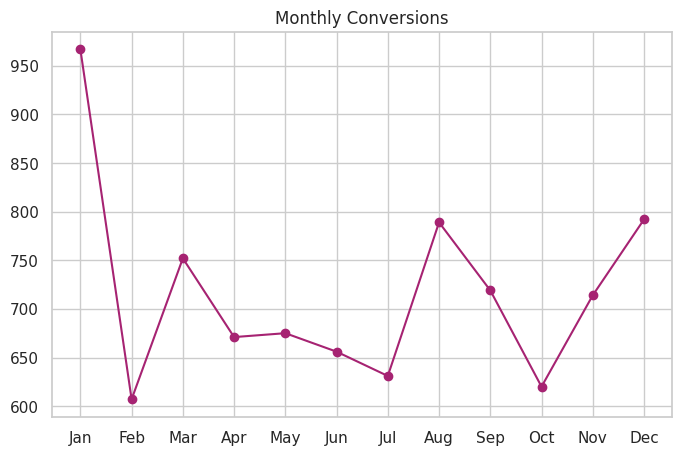

In [49]:
plt.figure(figsize=(8,5))

plt.title('Monthly Conversions')

monthly_conversion = df.groupby('month')[['Facebook Ad Conversions']].sum()

month_names = [
    'Jan', 'Feb', 'Mar', 'Apr',
    'May', 'Jun', 'Jul', 'Aug',
    'Sep', 'Oct', 'Nov', 'Dec'
]

plt.plot(
    month_names,
    monthly_conversion['Facebook Ad Conversions'],
    '-o',
    color='#A62372'
)

plt.show()

1.January achieved the highest number of Facebook ad conversions.

2.February and October recorded comparatively lower conversion performance.

3.Seasonal conversion trends should be considered when planning future marketing campaigns and allocating advertising budgets.

**Q.How does the Cost Per Conversion (CPC) trend over time?**

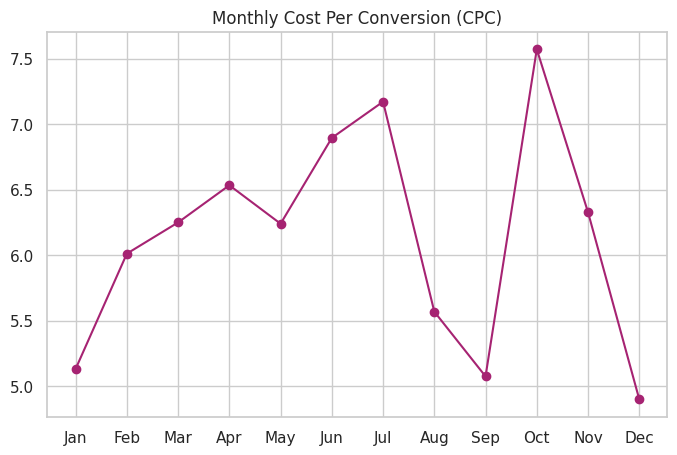

In [50]:
plt.figure(figsize=(8,5))

plt.title('Monthly Cost Per Conversion (CPC)')

monthly_df = df.groupby('month')[['Facebook Ad Conversions',
                                  'Cost per Facebook Ad']].sum()

monthly_df['Cost per Conversion'] = (
    monthly_df['Cost per Facebook Ad'] /
    monthly_df['Facebook Ad Conversions']
)

plt.plot(
    month_names,
    monthly_df['Cost per Conversion'],
    '-o',
    color='#A62372'
)

plt.show()

1.CPC fluctuated throughout the year, reflecting changes in advertising efficiency.

2.October had the highest CPC, making it the least cost-effective month.
3.December recorded the lowest CPC, indicating the most efficient campaign performance.

4.CPC improved during the final months of the year, suggesting better budget utilization.

5.Businesses should allocate more budget during low-CPC periods and investigate the causes of high CPC in months like October.

**Q.Is there a long-term equilibrium relationship between advertising spend and conversion rates that suggests a stable, proportional impact of budget changes on conversions over time?**

In [51]:
score, p_value, _ = coint(
    df['Cost per Facebook Ad'],
    df['Facebook Ad Conversions']
)

print('Cointegration test score:', score)

print('P-value:', p_value)

if p_value < 0.05:
    print("\np-value is less than significance value, Reject the null hypothesis")
else:
    print("\np-value is greater than significance value, Accept the null hypothesis")

Cointegration test score: -18.790813817382926
P-value: 1.3415283402362578e-29

p-value is less than significance value, Reject the null hypothesis


1.The null hypothesis was rejected, confirming that advertising spend and conversions move together over time in this dataset.

2.The findings suggest that optimizing advertising budgets can support sustained conversion performance.

3.Businesses should monitor advertising costs and conversions together to improve ROI and long-term campaign effectiveness.